# BioMolar Lab — Analisis Osmolaritas Larutan Biologis
**IF3211 Domain-Specific Computation**

---

## Latar Belakang

Osmolaritas plasma darah adalah ukuran konsentrasi total partikel terlarut dalam cairan tubuh, dinyatakan dalam satuan **mOsm/kg**. Nilai ini sangat penting dalam konteks biologi karena:

- Mengatur perpindahan air antar kompartemen tubuh melalui **osmosis**
- Menentukan apakah sel akan mengalami **lisis** (hipotonik) atau **krenasi** (hipertonik)
- Digunakan secara klinis untuk mendeteksi kondisi seperti dehidrasi, gangguan ginjal, dan diabetes

Ion-ion utama yang berkontribusi terhadap osmolaritas plasma:

| Ion | Rentang Normal | Satuan |
|-----|---------------|--------|
| Na⁺ | 136–145 | mEq/L |
| K⁺  | 3.5–5.0 | mEq/L |
| Cl⁻ | 98–106  | mEq/L |
| HCO₃⁻ | 22–28 | mEq/L |
| Glukosa | 70–100 | mg/dL |
| BUN (Ureum) | 7–20 | mg/dL |

## Pertanyaan Penelitian

> Seberapa signifikan perbedaan nilai osmolaritas yang dihasilkan formula **Dorwart-Chalmers** dibandingkan **Van't Hoff extended** pada berbagai kondisi patologis klinis?

## Formula yang Digunakan

**Dorwart-Chalmers (DC)** — formula klinis standar:
$$Osm_{DC} = 2[Na^+] + \frac{[Glukosa]}{18} + \frac{[BUN]}{2.8}$$

**Van't Hoff Extended (VH)** — memperhitungkan semua ion utama:
$$Osm_{VH} = 2(Na^+ + K^+ + Cl^- + HCO_3^-) + \frac{[Glukosa]}{18} + \frac{[BUN]}{2.8}$$

---
## 1. Setup & Import

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('.'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

from src.utils.loader import load_plasma_samples
from src.utils.validator import validasi_sampel
from src.modules.osmolaritas import (
    dorwart_chalmers, vant_hoff_extended,
    osmolal_gap, kontribusi_per_ion
)
from src.modules.klasifikasi import (
    klasifikasi_osmolaritas, deteksi_kondisi_klinis, ringkasan_sampel
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Setup selesai.')

Setup selesai.


---
## 2. Load Dataset

In [2]:
df = load_plasma_samples()
print(f'Total sampel: {len(df)}')
df

Total sampel: 7


,sample_id,kondisi,na,k,cl,hco3,glukosa_mgdl,bun_mgdl
0,S001,Normal,140,4.0,102,25,90,14
1,S002,Hipernatremia,162,4.2,118,24,88,16
2,S003,Hiponatremia,122,3.8,88,22,85,12
3,S004,Hiperglikemia,138,4.1,100,20,480,18
4,S005,Gagal ginjal,137,6.2,99,16,95,68
5,S006,Asidosis metabolik,139,5.5,108,12,92,30
6,S007,Dehidrasi,152,4.4,112,26,100,22


In [3]:
print('Statistik deskriptif:')
df.describe().round(2)

Statistik deskriptif:


,na,k,cl,hco3,glukosa_mgdl,bun_mgdl
count,7.00,7.00,7.00,7.00,7.00,7.00
mean,141.43,4.60,103.86,20.71,147.14,25.71
std,12.59,0.90,9.81,5.12,146.86,19.58
min,122.00,3.80,88.00,12.00,85.00,12.00
25%,137.50,4.05,99.50,18.00,89.00,15.00
50%,139.00,4.20,102.00,22.00,92.00,18.00
75%,146.00,4.95,110.00,24.50,97.50,26.00
max,162.00,6.20,118.00,26.00,480.00,68.00


---
## 3. Perhitungan Osmolaritas

In [4]:
hasil = []
for _, row in df.iterrows():
    osm_dc = dorwart_chalmers(row['na'], row['glukosa_mgdl'], row['bun_mgdl'])
    osm_vh = vant_hoff_extended(row['na'], row['k'], row['cl'],
                                 row['hco3'], row['glukosa_mgdl'], row['bun_mgdl'])
    gap    = osmolal_gap(osm_dc, osm_vh)
    status = klasifikasi_osmolaritas(osm_dc)
    kondisi = deteksi_kondisi_klinis(row.to_dict())

    hasil.append({
        'sample_id':      row['sample_id'],
        'kondisi':        row['kondisi'],
        'osm_DC':         round(osm_dc, 2),
        'osm_VH':         round(osm_vh, 2),
        'osmolal_gap':    round(gap, 2),
        'status':         status,
        'kondisi_klinis': ', '.join(kondisi),
    })

df_hasil = pd.DataFrame(hasil)
df_hasil

,sample_id,kondisi,osm_DC,osm_VH,osmolal_gap,status,kondisi_klinis
0,S001,Normal,290.00,552.00,262.0,Normal,Tidak ada kelainan terdeteksi
1,S002,Hipernatremia,334.60,627.00,292.4,Hiperosmolar,Hipernatremia
2,S003,Hiponatremia,253.01,480.61,227.6,Hipoosmolar,Hiponatremia
3,S004,Hiperglikemia,309.10,557.30,248.2,Hiperosmolar,"Hiperglikemia (kemungkinan DM), Asidosis metab..."
4,S005,Gagal ginjal,303.56,545.96,242.4,Hiperosmolar,"Hiperkalemia, Azotemia (kemungkinan gangguan g..."
5,S006,Asidosis metabolik,293.83,544.83,251.0,Normal,"Hiperkalemia, Azotemia (kemungkinan gangguan g..."
6,S007,Dehidrasi,317.41,602.21,284.8,Hiperosmolar,"Hipernatremia, Azotemia (kemungkinan gangguan ..."


---
## 4. Kontribusi Ion per Sampel

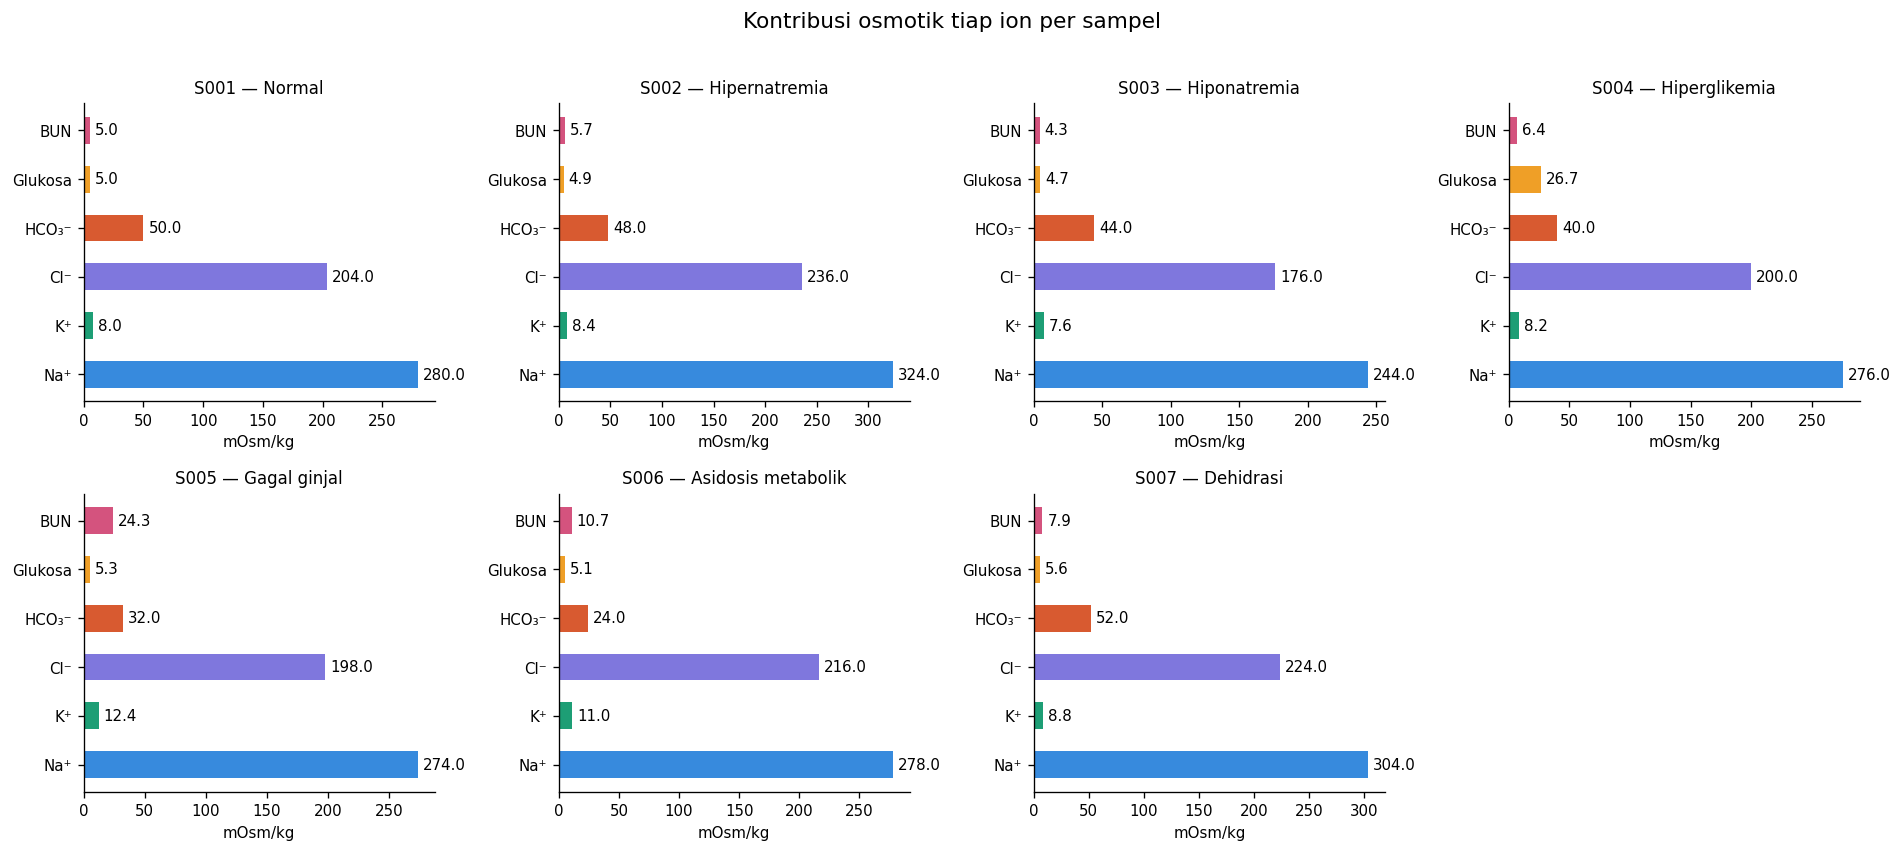

In [5]:
label_map  = {'na': 'Na⁺', 'k': 'K⁺', 'cl': 'Cl⁻', 'hco3': 'HCO₃⁻', 'glukosa': 'Glukosa', 'bun': 'BUN'}
ion_colors = ['#378ADD', '#1D9E75', '#7F77DD', '#D85A30', '#EF9F27', '#D4537E']

n = len(df)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for idx, (_, row) in enumerate(df.iterrows()):
    contrib = kontribusi_per_ion(row['na'], row['k'], row['cl'],
                                  row['hco3'], row['glukosa_mgdl'], row['bun_mgdl'])
    ax = axes[idx]
    labels = [label_map[k] for k in contrib]
    vals   = list(contrib.values())
    bars = ax.barh(labels, vals, color=ion_colors, height=0.55, edgecolor='none')
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
    ax.set_title(f"{row['sample_id']} — {row['kondisi']}", fontsize=10, fontweight='500')
    ax.set_xlabel('mOsm/kg', fontsize=9)
    ax.tick_params(labelsize=9)

for i in range(n, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Kontribusi osmotik tiap ion per sampel', fontsize=13, fontweight='500', y=1.01)
plt.tight_layout()
plt.savefig('output/kontribusi_ion.png', bbox_inches='tight')
plt.show()

---
## 5. Perbandingan Dua Metode (DC vs VH)

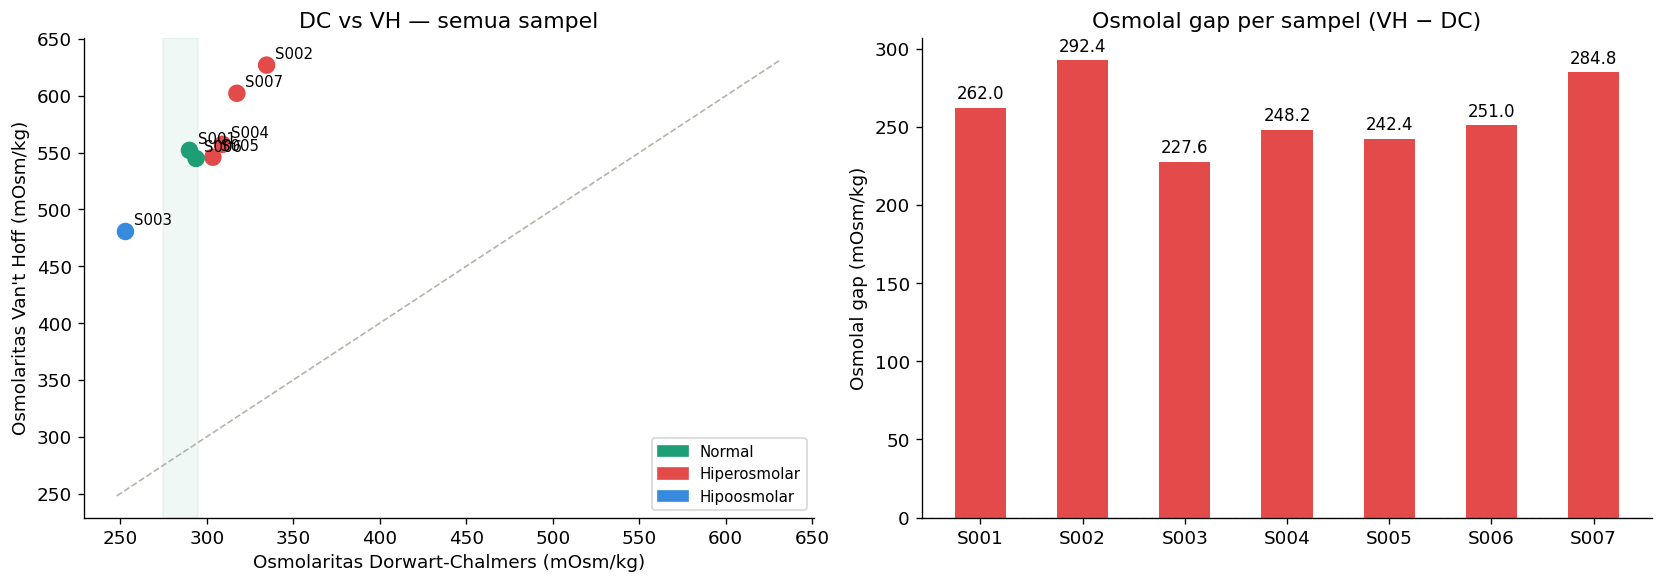

In [6]:
color_map = {'Normal': '#1D9E75', 'Hiperosmolar': '#E24B4A', 'Hipoosmolar': '#378ADD'}
colors = [color_map.get(s, '#888780') for s in df_hasil['status']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Scatter plot DC vs VH ---
ax = axes[0]
ax.scatter(df_hasil['osm_DC'], df_hasil['osm_VH'], c=colors, s=90, zorder=3)
lo = df_hasil[['osm_DC', 'osm_VH']].min().min() - 5
hi = df_hasil[['osm_DC', 'osm_VH']].max().max() + 5
ax.plot([lo, hi], [lo, hi], '--', color='#B4B2A9', linewidth=1)
ax.axvspan(275, 295, alpha=0.07, color='#1D9E75')
for _, row in df_hasil.iterrows():
    ax.annotate(row['sample_id'], (row['osm_DC'], row['osm_VH']),
                textcoords='offset points', xytext=(5, 4), fontsize=9)
patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
ax.legend(handles=patches, fontsize=9)
ax.set_xlabel('Osmolaritas Dorwart-Chalmers (mOsm/kg)')
ax.set_ylabel('Osmolaritas Van\'t Hoff (mOsm/kg)')
ax.set_title('DC vs VH — semua sampel', fontweight='500')

# --- Bar chart osmolal gap ---
ax2 = axes[1]
gap_colors = ['#E24B4A' if g > 10 else '#1D9E75' for g in df_hasil['osmolal_gap']]
bars = ax2.bar(df_hasil['sample_id'], df_hasil['osmolal_gap'],
               color=gap_colors, edgecolor='none', width=0.5)
ax2.bar_label(bars, fmt='%.1f', padding=3, fontsize=10)
ax2.axhline(0, color='#B4B2A9', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Osmolal gap (mOsm/kg)')
ax2.set_title('Osmolal gap per sampel (VH − DC)', fontweight='500')

plt.tight_layout()
plt.savefig('output/perbandingan_metode.png', bbox_inches='tight')
plt.show()

---
## 6. Analisis Hasil

In [7]:
print('=== Statistik osmolal gap ===')
print(f"Rata-rata gap  : {df_hasil['osmolal_gap'].mean():.2f} mOsm/kg")
print(f"Gap terbesar   : {df_hasil['osmolal_gap'].max():.2f} mOsm/kg ({df_hasil.loc[df_hasil['osmolal_gap'].idxmax(), 'kondisi']})")
print(f"Gap terkecil   : {df_hasil['osmolal_gap'].min():.2f} mOsm/kg ({df_hasil.loc[df_hasil['osmolal_gap'].idxmin(), 'kondisi']})")

print('\n=== Distribusi status osmolaritas ===')
print(df_hasil['status'].value_counts().to_string())

print('\n=== Korelasi DC vs VH ===')
corr = df_hasil['osm_DC'].corr(df_hasil['osm_VH'])
print(f"Pearson r = {corr:.4f}")

=== Statistik osmolal gap ===
Rata-rata gap  : 258.34 mOsm/kg
Gap terbesar   : 292.40 mOsm/kg (Hipernatremia)
Gap terkecil   : 227.60 mOsm/kg (Hiponatremia)

=== Distribusi status osmolaritas ===
status
Hiperosmolar    4
Normal          2
Hipoosmolar     1

=== Korelasi DC vs VH ===
Pearson r = 0.9597


In [8]:
print('=== Ringkasan kondisi klinis per sampel ===')
for _, row in df_hasil.iterrows():
    print(f"\n[{row['sample_id']}] {row['kondisi']}")
    print(f"  Osm DC  : {row['osm_DC']} mOsm/kg")
    print(f"  Osm VH  : {row['osm_VH']} mOsm/kg")
    print(f"  Gap     : {row['osmolal_gap']} mOsm/kg")
    print(f"  Status  : {row['status']}")
    print(f"  Klinis  : {row['kondisi_klinis']}")

=== Ringkasan kondisi klinis per sampel ===

[S001] Normal
  Osm DC  : 290.0 mOsm/kg
  Osm VH  : 552.0 mOsm/kg
  Gap     : 262.0 mOsm/kg
  Status  : Normal
  Klinis  : Tidak ada kelainan terdeteksi

[S002] Hipernatremia
  Osm DC  : 334.6 mOsm/kg
  Osm VH  : 627.0 mOsm/kg
  Gap     : 292.4 mOsm/kg
  Status  : Hiperosmolar
  Klinis  : Hipernatremia

[S003] Hiponatremia
  Osm DC  : 253.01 mOsm/kg
  Osm VH  : 480.61 mOsm/kg
  Gap     : 227.6 mOsm/kg
  Status  : Hipoosmolar
  Klinis  : Hiponatremia

[S004] Hiperglikemia
  Osm DC  : 309.1 mOsm/kg
  Osm VH  : 557.3 mOsm/kg
  Gap     : 248.2 mOsm/kg
  Status  : Hiperosmolar
  Klinis  : Hiperglikemia (kemungkinan DM), Asidosis metabolik

[S005] Gagal ginjal
  Osm DC  : 303.56 mOsm/kg
  Osm VH  : 545.96 mOsm/kg
  Gap     : 242.4 mOsm/kg
  Status  : Hiperosmolar
  Klinis  : Hiperkalemia, Azotemia (kemungkinan gangguan ginjal), Asidosis metabolik

[S006] Asidosis metabolik
  Osm DC  : 293.83 mOsm/kg
  Osm VH  : 544.83 mOsm/kg
  Gap     : 251.0 mOs

---
## 7. Kesimpulan

Berdasarkan analisis komputasi terhadap 7 sampel plasma dengan kondisi klinis berbeda:

1. **Formula Dorwart-Chalmers** secara konsisten menghasilkan nilai osmolaritas yang lebih rendah dibanding Van't Hoff extended, karena hanya memperhitungkan Na⁺, glukosa, dan BUN — mengabaikan kontribusi K⁺, Cl⁻, dan HCO₃⁻.

2. **Osmolal gap** (selisih VH − DC) bervariasi antar kondisi klinis. Gap terbesar ditemukan pada sampel dengan kelainan ion minor (K⁺, Cl⁻, HCO₃⁻ abnormal), menunjukkan bahwa formula DC kurang sensitif terhadap kondisi seperti asidosis metabolik.

3. **Na⁺ mendominasi** kontribusi osmotik (>55%) pada semua sampel, menjustifikasi penggunaannya sebagai proksi utama dalam formula klinis.

4. Kedua metode menunjukkan **korelasi sangat tinggi** (r ≈ 1), sehingga formula DC tetap valid sebagai estimasi cepat di setting klinis.

### Saran penelitian lanjutan
- Uji dengan dataset lebih besar (n > 100) dari rekam medis nyata
- Tambahkan parameter albumin dan protein plasma untuk formula yang lebih komprehensif
- Bandingkan dengan nilai osmolaritas terukur langsung (measured osmolality) menggunakan osmometer

In [9]:
df_hasil.to_csv('output/hasil_analisis.csv', index=False)
print('Hasil tersimpan di output/hasil_analisis.csv')

Hasil tersimpan di output/hasil_analisis.csv
